## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd
import seaborn as sns
import random as rand

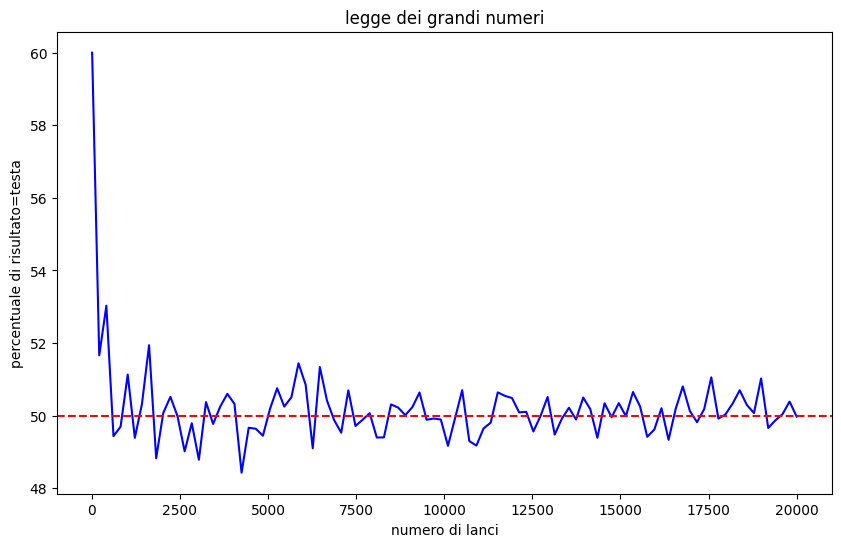

In [3]:
def simulazione_lanci(N):
    lanci=[rand.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=np.linspace(10,20000,100)

risultati_campioni=[simulazione_lanci(int(n)) for n in campioni] 
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

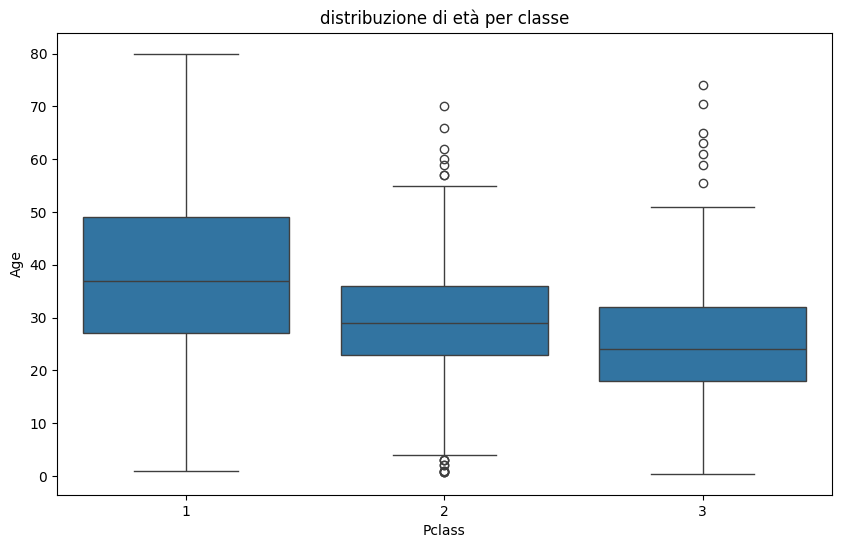

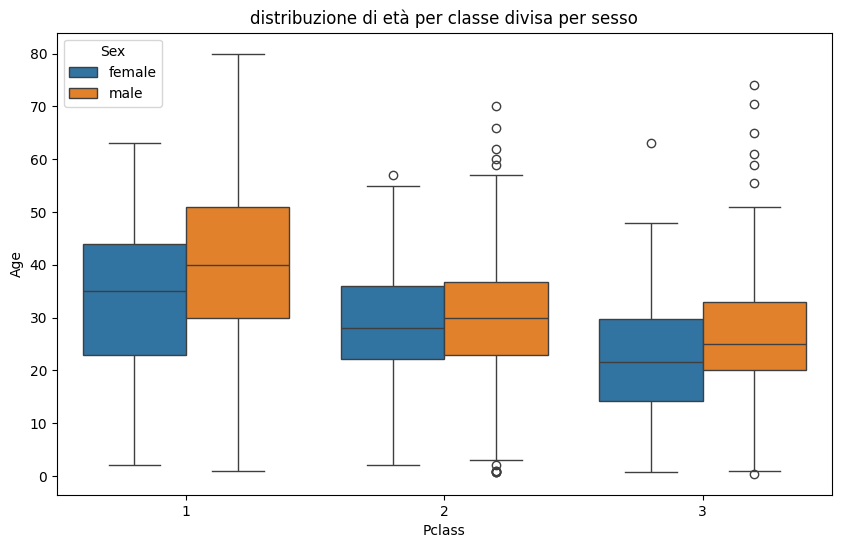

In [ ]:

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

dimesione_df=[df.shape[0],df.shape[1]]
valori_mancanti=df.isnull().sum()
df["Embarked"].fillna(df["Embarked"].mode()[0])
righe_duplicate=df.duplicated().sum()
df["Age"].fillna(df["Age"].mean())
età_media_passeggeri_per_classe=df.groupby("Pclass")["Age"].mean()

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Pclass",y="Age")
plt.title("distribuzione di età per classe")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Pclass",y="Age",hue="Sex")
plt.title("distribuzione di età per classe divisa per sesso")
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

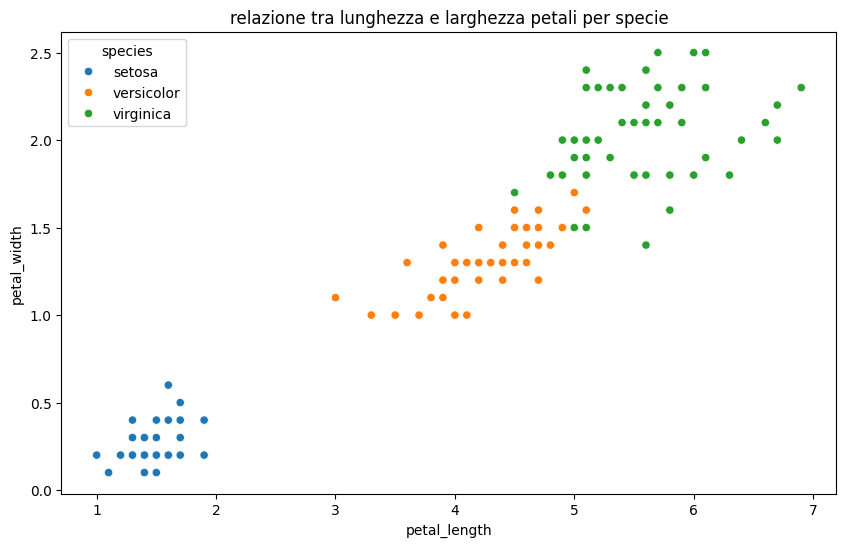

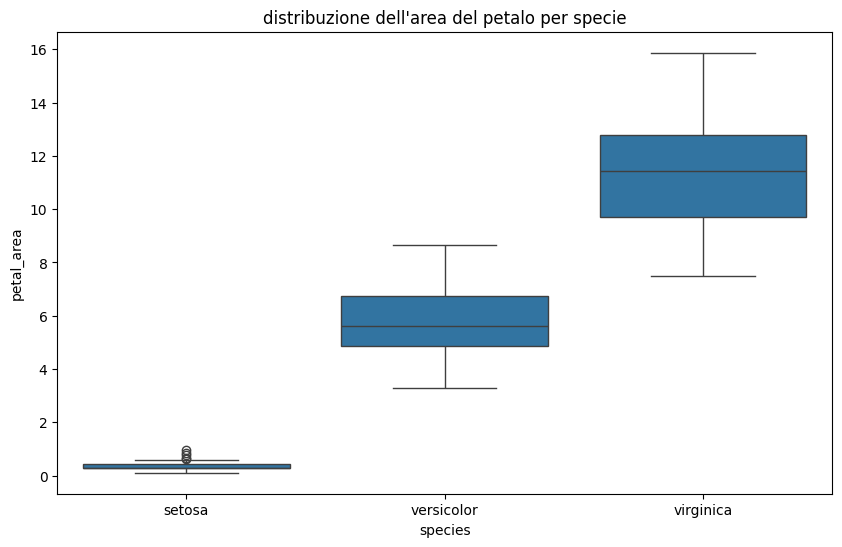

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

num_specie=len(df["species"].unique())   
lunghezza_media_petalo_per_specie=df.groupby("species")["petal_length"].mean()
larghezza_media_petalo_per_specie=df.groupby("species")["petal_width"].mean()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("relazione tra lunghezza e larghezza petali per specie")
plt.show() 

df["petal_area"] = df["petal_length"] * df["petal_width"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="species", y="petal_area")
plt.title("distribuzione dell'area del petalo per specie")
plt.show()